In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pymc as pm
import arviz as az
from itertools import combinations
from itertools import permutations
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.covariance import MinCovDet
from skbio.stats.distance import permanova, DistanceMatrix
from scipy.stats import f_oneway
from scipy.stats import chi2
from scipy.spatial.distance import pdist, squareform
from scipy.spatial.distance import euclidean
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
c:\Users\Welton Dionisio\AppData\Local\Programs\Python\Python314\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
arquivo = Path.cwd() / "morphometrics.xlsx"

morfo = pd.read_excel(arquivo, engine="openpyxl")
morfo.head()

,Sample,tombo,local,species,period,size,dorsal_button,ventral_button,feet_button,dorsal_tables,...,dorsal_basket,ventral_basket,dorsal_wheel,ventral_wheel,ph,temperature,oxygen,ec,salinity,ppt
0,1,3007P,Genipabu,Holothuria grisea,Rainy,114.0,0.00535,0.00485,0.00465,NaN,...,NaN,NaN,NaN,NaN,9.30,31.0,117.0,51.0,27.4,25.0
1,1,3007G,Genipabu,Holothuria grisea,Rainy,116.0,0.00420,0.00325,0.00295,NaN,...,NaN,NaN,NaN,NaN,9.30,31.0,117.0,51.0,27.4,25.0
2,2,2917M,Genipabu,Holothuria grisea,Rainy,115.0,0.00325,0.00375,0.00365,NaN,...,NaN,NaN,NaN,NaN,8.50,30.9,134.0,44.0,28.0,22.5
3,2,2918,Genipabu,Holothuria grisea,Rainy,120.0,0.00335,0.00375,0.00375,NaN,...,NaN,NaN,NaN,NaN,8.50,30.9,134.0,44.0,28.0,22.5
4,3,3004,Genipabu,Holothuria grisea,Rainy,145.0,0.00345,0.00375,0.00345,NaN,...,NaN,NaN,NaN,NaN,7.25,29.3,124.0,72.9,29.0,34.6


In [3]:
# Select the correct columns for PCA
X = morfo.iloc[:, 6:26].copy()
X = X.apply(pd.to_numeric, errors='coerce')

# Impute missing values using the median within each species
species_median = X.groupby(morfo['species']).transform('median')
X_imputed = X.fillna(species_median)

# If the species median is unavailable, use the overall median
X_imputed = X_imputed.fillna(X.median())

# Check remaining missing values
print(f'Remaining missing values: {X_imputed.isna().sum().sum()}')

# Standardize the imputed data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# PCA retaining enough components to explain >75% of variance
pca = PCA(n_components=0.75, svd_solver='full')
X_pca = pca.fit_transform(X_scaled)

print(f'Number of retained PCs: {pca.n_components_}')
print(pca.explained_variance_ratio_)
print(f'Cumulative variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%')

loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

print(loadings)

Remaining missing values: 0
Number of retained PCs: 4
[0.4170208  0.14862596 0.11519536 0.0808355 ]
Cumulative variance explained: 76.17%
                     PC1       PC2       PC3           PC4
dorsal_button   0.357434  0.072056 -0.060371 -2.407706e-03
ventral_button -0.017532  0.373894 -0.263239 -1.030213e-02
feet_button    -0.011050  0.242467 -0.293194 -1.427314e-02
dorsal_tables   0.356773  0.055051 -0.042057 -1.966449e-03
ventral_tables  0.356634 -0.057111  0.079508  5.154668e-04
feet_tables     0.358997 -0.036415  0.057115  8.719933e-05
dorsal__plate   0.336242 -0.003495 -0.027043  3.667806e-03
ventral_plate   0.337687  0.028459 -0.038874  1.174104e-03
feet_plate      0.357238  0.042872 -0.092827 -3.761626e-03
entacle_plate   0.000000 -0.000000  0.000000  1.110223e-16
dorsal_rods    -0.025981  0.426858  0.471522  2.714551e-03
ventral_rods   -0.030298  0.434576  0.464421  1.994917e-02
feet_rods      -0.024992  0.516594 -0.239475 -1.135256e-03
tentacle_rods   0.093107 -0.322176  

In [4]:
# PCs
pc_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4'])

# Concatenate the PCA results with the 'local' and 'period' columns from the original DataFrame
df_model = pd.concat(
    [pc_df, morfo[['local', 'period']].reset_index(drop=True)],
    axis=1
)

print(df_model.head())

        PC1       PC2       PC3       PC4     local period
0  0.218768 -1.214664  0.973917 -0.018808  Genipabu  Rainy
1  0.354960 -3.606431  3.139170  0.070303  Genipabu  Rainy
2  0.227347 -2.513101  1.978536  0.033255  Genipabu  Rainy
3  0.246260 -2.538902  2.027178  0.031799  Genipabu  Rainy
4  0.286650 -2.793454  2.363465  0.041923  Genipabu  Rainy


In [6]:
# Count individuals by species × locality × period
count_table = (
    morfo[['species', 'local', 'period']]
    .dropna()
    .groupby(['species', 'local', 'period'])
    .size()
    .reset_index(name='n')
)

# Include combinations with zero individuals
species_levels = sorted(morfo['species'].dropna().unique())
local_levels = sorted(morfo['local'].dropna().unique())
period_levels = sorted(morfo['period'].dropna().unique())

full_index = pd.MultiIndex.from_product(
    [species_levels, local_levels, period_levels],
    names=['species', 'local', 'period']
)

count_table = (
    count_table
    .set_index(['species', 'local', 'period'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

print(count_table)

# Publication-style table
count_pivot = count_table.pivot_table(
    index='species',
    columns=['local', 'period'],
    values='n',
    fill_value=0,
    aggfunc='sum'
).astype(int)

print('\nSpecies × locality × period:')
print(count_pivot)

                    species        local period   n
0        Chiridota rotifera      Formosa    Dry   0
1        Chiridota rotifera      Formosa  Rainy   3
2        Chiridota rotifera     Genipabu    Dry   0
3        Chiridota rotifera     Genipabu  Rainy   1
4        Chiridota rotifera  Pirambúzios    Dry  19
5        Chiridota rotifera  Pirambúzios  Rainy  13
6        Chiridota rotifera      Tambaba    Dry   0
7        Chiridota rotifera      Tambaba  Rainy   0
8         Holothuria grisea      Formosa    Dry   0
9         Holothuria grisea      Formosa  Rainy   0
10        Holothuria grisea     Genipabu    Dry   4
11        Holothuria grisea     Genipabu  Rainy  11
12        Holothuria grisea  Pirambúzios    Dry   0
13        Holothuria grisea  Pirambúzios  Rainy   0
14        Holothuria grisea      Tambaba    Dry   0
15        Holothuria grisea      Tambaba  Rainy   2
16  Parathyone brasiliensis      Formosa    Dry   2
17  Parathyone brasiliensis      Formosa  Rainy   0
18  Parathyo

In [7]:
def make_design(data, terms):
    parts = [np.ones((len(data), 1))]
    for term in terms:
        dummies = pd.get_dummies(
            data[term].astype('category'),
            drop_first=True,
            dtype=float
        ).to_numpy()
        if dummies.shape[1] > 0:
            parts.append(dummies)
    return np.column_stack(parts)

def fit_model(Y, X):
    beta = np.linalg.lstsq(X, Y, rcond=None)[0]
    fitted = X @ beta
    residuals = Y - fitted
    return np.sum(residuals**2), fitted, residuals, np.linalg.matrix_rank(X)

def partial_permanova(Y, data, target, covariates=None, permutations=999, random_state=42):
    covariates = covariates or []
    X_reduced = make_design(data, covariates)
    X_full = make_design(data, covariates + [target])

    sse_red, fitted_red, resid_red, rank_red = fit_model(Y, X_reduced)
    sse_full, _, _, rank_full = fit_model(Y, X_full)

    df_effect = rank_full - rank_red
    df_resid = len(Y) - rank_full
    ss_effect = sse_red - sse_full

    if np.isclose(ss_effect, 0):
        ss_effect = 0.0

    if df_effect <= 0 or df_resid <= 0 or sse_full <= np.finfo(float).eps:
        return pd.Series({
            'test': f'{target} | {", ".join(covariates)}',
            'pseudo-F': np.nan,
            'partial R2': np.nan,
            'p-value': np.nan,
            'df effect': df_effect,
            'df residual': df_resid,
            'permutations': permutations
        })

    F_obs = (ss_effect / df_effect) / (sse_full / df_resid)
    rng = np.random.default_rng(random_state)
    F_perm = np.full(permutations, np.nan)

    for i in range(permutations):
        Y_perm = fitted_red + resid_red[rng.permutation(len(Y))]
        sse_red_p, _, _, _ = fit_model(Y_perm, X_reduced)
        sse_full_p, _, _, _ = fit_model(Y_perm, X_full)

        if sse_full_p > np.finfo(float).eps:
            F_perm[i] = ((sse_red_p - sse_full_p) / df_effect) / (sse_full_p / df_resid)

    F_perm = F_perm[np.isfinite(F_perm)]
    p_value = (
        (np.sum(F_perm >= F_obs) + 1) / (len(F_perm) + 1)
        if len(F_perm) else np.nan
    )

    denominator = ss_effect + sse_full
    partial_r2 = ss_effect / denominator if denominator > 0 else np.nan

    return pd.Series({
        'test': f'{target} | {", ".join(covariates)}',
        'pseudo-F': F_obs,
        'partial R2': partial_r2,
        'p-value': p_value,
        'df effect': df_effect,
        'df residual': df_resid,
        'permutations': permutations
    })

# Prepare Sample × species units
mask = morfo[['Sample', 'local', 'species']].notna().all(axis=1)
pc_cols = ['PC1', 'PC2', 'PC3', 'PC4']

perm_data = morfo.loc[
    mask, ['Sample', 'local', 'species']
].reset_index(drop=True)

perm_data[pc_cols] = X_pca[mask.to_numpy(), :4]

perm_data = (
    perm_data
    .groupby(['Sample', 'local', 'species'], as_index=False)[pc_cols]
    .mean()
)

X_pca_valid = perm_data[pc_cols].to_numpy()
meta = perm_data[['Sample', 'local', 'species']].copy()

print(f'PCA Valid Shape: {X_pca_valid.shape}')
print(f'Unique samples: {meta["Sample"].nunique()}')
print(f'Sample × species units: {len(meta)}')
print(f'Cumulative variance explained: {pca.explained_variance_ratio_[:4].sum()*100:.2f}%')

res = partial_permanova(
    X_pca_valid,
    meta,
    target='local',
    covariates=['species'],
    permutations=999,
    random_state=42
)

print('\nPERMANOVA: locality controlling for species')
print(res)

PCA Valid Shape: (46, 4)
Unique samples: 43
Sample × species units: 46
Cumulative variance explained: 76.17%

PERMANOVA: locality controlling for species
test            local | species
pseudo-F               1.896559
partial R2              0.13328
p-value                   0.152
df effect                     3
df residual                  37
permutations                999
dtype: object


In [8]:
# Keep observations with complete sampling information
mask = morfo[['Sample', 'local', 'species']].notna().all(axis=1).to_numpy(dtype=bool)

pc_cols = ['PC1', 'PC2', 'PC3', 'PC4']

perm_data = morfo.loc[
    mask, ['Sample', 'local', 'species']
].reset_index(drop=True)

perm_data[pc_cols] = X_pca[mask, :4]

# Average individuals within each Sample × species
perm_data = (
    perm_data
    .groupby(['Sample', 'local', 'species'], as_index=False)[pc_cols]
    .mean()
)

X_pca_valid = perm_data[pc_cols].to_numpy()
meta = perm_data[['Sample', 'local', 'species']].copy()

# Confirm the PCs and sampling units used
print(f'Shape: {X_pca_valid.shape}')
print(f'PCs used: {X_pca_valid.shape[1]}')
print(f'Cumulative variance explained: {pca.explained_variance_ratio_[:4].sum()*100:.2f}%')
print(f'Unique samples: {meta["Sample"].nunique()}')
print(f'Sample × species units: {len(meta)}')

groups = meta['local'].astype(str).to_numpy()
unique_groups = np.unique(groups)
results = []

# Pairwise PERMANOVA controlling for species
for g1, g2 in combinations(unique_groups, 2):
    mask_pair = (groups == g1) | (groups == g2)

    Y_pair = X_pca_valid[mask_pair]
    meta_pair = meta.loc[mask_pair].reset_index(drop=True)

    res = partial_permanova(
        Y_pair,
        meta_pair,
        target='local',
        covariates=['species'],
        permutations=999,
        random_state=42
    )

    results.append({
        'group1': g1,
        'group2': g2,
        'F': res['pseudo-F'],
        'partial_R2': res['partial R2'],
        'p': res['p-value']
    })

df_posthoc = pd.DataFrame(results)

# FDR correction for estimable comparisons
valid = df_posthoc['p'].notna()
df_posthoc['p_adj'] = np.nan

df_posthoc.loc[valid, 'p_adj'] = multipletests(
    df_posthoc.loc[valid, 'p'],
    method='fdr_bh'
)[1]

df_posthoc = df_posthoc.sort_values('p_adj', na_position='last')

print('\nPairwise PERMANOVA controlling for species')
print(df_posthoc)

# Check species shared between locality pairs
for g1, g2 in combinations(unique_groups, 2):
    meta_pair = meta[meta['local'].isin([g1, g2])]

    shared_species = (
        meta_pair.groupby('species')['local']
        .nunique()
        .loc[lambda x: x == 2]
        .index.tolist()
    )

    print(f'{g1} vs {g2}: {len(shared_species)} shared species')

Shape: (46, 4)
PCs used: 4
Cumulative variance explained: 76.17%
Unique samples: 43
Sample × species units: 46

Pairwise PERMANOVA controlling for species
        group1       group2         F  partial_R2      p  p_adj
4     Genipabu      Tambaba  6.994819    0.304191  0.023  0.092
0      Formosa     Genipabu  2.101594    0.095088  0.164  0.240
1      Formosa  Pirambúzios  1.753610    0.077070  0.180  0.240
3     Genipabu  Pirambúzios  0.600031    0.036146  0.385  0.385
2      Formosa      Tambaba       NaN         NaN    NaN    NaN
5  Pirambúzios      Tambaba       NaN         NaN    NaN    NaN
Formosa vs Genipabu: 1 shared species
Formosa vs Pirambúzios: 2 shared species
Formosa vs Tambaba: 0 shared species
Genipabu vs Pirambúzios: 1 shared species
Genipabu vs Tambaba: 1 shared species
Pirambúzios vs Tambaba: 0 shared species


In [9]:
# Prepare Sample × species units
mask = morfo[['Sample', 'local', 'species']].notna().all(axis=1).to_numpy(dtype=bool)
pc_cols = ['PC1', 'PC2', 'PC3', 'PC4']

perm_data = morfo.loc[mask, ['Sample', 'local', 'species']].reset_index(drop=True)
perm_data[pc_cols] = X_pca[mask, :4]
perm_data = perm_data.groupby(['Sample', 'local', 'species'], as_index=False)[pc_cols].mean()

Y = perm_data[pc_cols].to_numpy()
meta = perm_data[['Sample', 'local', 'species']].copy()

print(f'Sample × species units: {len(Y)}')
print(f'Unique samples: {meta["Sample"].nunique()}')
print(f'PCs used: {Y.shape[1]}')
print(f'Cumulative variance explained: {pca.explained_variance_ratio_[:4].sum()*100:.2f}%')

def make_design(data, terms):
    parts = [np.ones((len(data), 1))]
    for term in terms:
        dummies = pd.get_dummies(data[term].astype('category'), drop_first=True, dtype=float).to_numpy()
        if dummies.shape[1] > 0:
            parts.append(dummies)
    return np.column_stack(parts)

def fit_model(Y, X):
    beta = np.linalg.lstsq(X, Y, rcond=None)[0]
    fitted = X @ beta
    residuals = Y - fitted
    return np.sum(residuals**2), fitted, residuals, np.linalg.matrix_rank(X)

def partial_permanova(Y, data, target, covariates=None, permutations=999, random_state=42):
    covariates = covariates or []
    X_reduced = make_design(data, covariates)
    X_full = make_design(data, covariates + [target])

    sse_red, fitted_red, resid_red, rank_red = fit_model(Y, X_reduced)
    sse_full, _, _, rank_full = fit_model(Y, X_full)

    df_effect = rank_full - rank_red
    df_resid = len(Y) - rank_full
    ss_effect = sse_red - sse_full

    if np.isclose(ss_effect, 0):
        ss_effect = 0.0

    if df_effect <= 0 or df_resid <= 0 or sse_full <= np.finfo(float).eps:
        return pd.Series({
            'test': f'{target} | {", ".join(covariates)}',
            'pseudo-F': np.nan,
            'partial R2': np.nan,
            'p-value': np.nan,
            'df effect': df_effect,
            'df residual': df_resid,
            'permutations': permutations
        })

    F_obs = (ss_effect / df_effect) / (sse_full / df_resid)
    rng = np.random.default_rng(random_state)
    F_perm = np.full(permutations, np.nan)

    for i in range(permutations):
        Y_perm = fitted_red + resid_red[rng.permutation(len(Y))]
        sse_red_p, _, _, _ = fit_model(Y_perm, X_reduced)
        sse_full_p, _, _, _ = fit_model(Y_perm, X_full)

        if sse_full_p > np.finfo(float).eps:
            F_perm[i] = ((sse_red_p - sse_full_p) / df_effect) / (sse_full_p / df_resid)

    F_perm = F_perm[np.isfinite(F_perm)]
    p_value = (np.sum(F_perm >= F_obs) + 1) / (len(F_perm) + 1) if len(F_perm) else np.nan

    denominator = ss_effect + sse_full
    partial_r2 = ss_effect / denominator if denominator > 0 else np.nan

    return pd.Series({
        'test': f'{target} | {", ".join(covariates)}',
        'pseudo-F': F_obs,
        'partial R2': partial_r2,
        'p-value': p_value,
        'df effect': df_effect,
        'df residual': df_resid,
        'permutations': permutations
    })

def distances_to_centroids(Y, groups):
    groups = np.asarray(groups, dtype=str)
    distances = np.zeros(len(Y), dtype=float)

    for group in np.unique(groups):
        idx = groups == group
        centroid = Y[idx].mean(axis=0)
        distances[idx] = np.linalg.norm(Y[idx] - centroid, axis=1)

    return distances

def permdisp(Y, groups, permutations=999, random_state=42):
    groups = np.asarray(groups, dtype=str)
    unique_groups = np.unique(groups)
    group_sizes = np.array([np.sum(groups == g) for g in unique_groups])

    if np.any(group_sizes < 2):
        return (
            pd.Series({'F': np.nan, 'p-value': np.nan, 'permutations': permutations}),
            pd.DataFrame({
                'group': unique_groups,
                'n': group_sizes,
                'mean_distance': np.nan,
                'median_distance': np.nan
            }))

    distances = distances_to_centroids(Y, groups)
    samples = [distances[groups == g] for g in unique_groups]
    F_obs = f_oneway(*samples).statistic

    rng = np.random.default_rng(random_state)
    F_perm = np.full(permutations, np.nan)

    for i in range(permutations):
        perm_groups = rng.permutation(groups)
        perm_dist = distances_to_centroids(Y, perm_groups)
        perm_samples = [perm_dist[perm_groups == g] for g in unique_groups]
        F_perm[i] = f_oneway(*perm_samples).statistic

    F_perm = F_perm[np.isfinite(F_perm)]
    p_value = (
        (np.sum(F_perm >= F_obs) + 1) / (len(F_perm) + 1)
        if np.isfinite(F_obs) and len(F_perm) else np.nan
    )

    dispersion = pd.DataFrame({
        'group': unique_groups,
        'n': group_sizes,
        'mean_distance': [distances[groups == g].mean() for g in unique_groups],
        'median_distance': [np.median(distances[groups == g]) for g in unique_groups]
    })

    return pd.Series({
        'F': F_obs,
        'p-value': p_value,
        'permutations': permutations
    }), dispersion

def pairwise_permdisp(Y, groups, permutations=999, random_state=42):
    groups = np.asarray(groups, dtype=str)
    results = []

    for g1, g2 in combinations(np.unique(groups), 2):
        idx = (groups == g1) | (groups == g2)
        res, disp = permdisp(Y[idx], groups[idx], permutations, random_state)

        if pd.isna(res['p-value']):
            mean1 = mean2 = np.nan
        else:
            mean1 = disp.loc[disp['group'] == g1, 'mean_distance'].iloc[0]
            mean2 = disp.loc[disp['group'] == g2, 'mean_distance'].iloc[0]

        results.append({
            'group1': g1,
            'group2': g2,
            'F': res['F'],
            'p': res['p-value'],
            'mean_dispersion_group1': mean1,
            'mean_dispersion_group2': mean2})

    out = pd.DataFrame(results)
    out['p_adj'] = np.nan
    valid = out['p'].notna()

    if valid.any():
        out.loc[valid, 'p_adj'] = multipletests(out.loc[valid, 'p'], method='fdr_bh')[1]

    out['significant'] = out['p_adj'] < 0.05
    return out.sort_values('p_adj', na_position='last').reset_index(drop=True)

# PERMANOVA
res_local = partial_permanova(
    Y, meta, target='local', covariates=['species'],
    permutations=999, random_state=42)

print('\nPERMANOVA: locality controlling for species')
print(res_local)

# PERMDISP
groups_local = meta['local'].astype(str).to_numpy()

res_disp, disp_table = permdisp(Y, groups_local, permutations=999, random_state=42)

print('\nPERMDISP: homogeneity of dispersion among localities')
print(res_disp)
print('\nDispersion by locality')
print(disp_table)

pairwise_disp = pairwise_permdisp(Y, groups_local, permutations=999, random_state=42)

print('\nPairwise PERMDISP among localities')
print(pairwise_disp)

# Species-adjusted PERMDISP
X_species = make_design(meta, ['species'])
_, _, Y_species_resid, _ = fit_model(Y, X_species)

res_disp_adjusted, disp_table_adjusted = permdisp(
    Y_species_resid, groups_local, permutations=999, random_state=42)

print('\nPERMDISP: locality after removing species effect')
print(res_disp_adjusted)
print('\nSpecies-adjusted dispersion by locality')
print(disp_table_adjusted)

pairwise_disp_adjusted = pairwise_permdisp(
    Y_species_resid, groups_local, permutations=999, random_state=42)

print('\nPairwise PERMDISP after controlling for species')
print(pairwise_disp_adjusted)

# Sensitivity analysis
res_local_unadjusted = partial_permanova(
    Y, meta, target='local', covariates=[],
    permutations=999, random_state=42)

res_local_adjusted = partial_permanova(
    Y, meta, target='local', covariates=['species'],
    permutations=999, random_state=42)

res_species_adjusted = partial_permanova(
    Y, meta, target='species', covariates=['local'],
    permutations=999, random_state=42)

sensitivity = pd.DataFrame({
    'Model': ['Locality only', 'Locality | Species', 'Species | Locality'],
    'Pseudo-F': [
        res_local_unadjusted['pseudo-F'],
        res_local_adjusted['pseudo-F'],
        res_species_adjusted['pseudo-F']
    ],
    'Partial_R2': [
        res_local_unadjusted['partial R2'],
        res_local_adjusted['partial R2'],
        res_species_adjusted['partial R2']
    ],
    'p_value': [
        res_local_unadjusted['p-value'],
        res_local_adjusted['p-value'],
        res_species_adjusted['p-value']
    ]})

print('\nSensitivity analysis: species as a control factor')
print(sensitivity)

F0 = res_local_unadjusted['pseudo-F']
R20 = res_local_unadjusted['partial R2']

F_change = ((res_local_adjusted['pseudo-F'] - F0) / F0 * 100
    if pd.notna(F0) and F0 != 0 else np.nan)

R2_change = ((res_local_adjusted['partial R2'] - R20) / R20 * 100
    if pd.notna(R20) and R20 != 0 else np.nan)

print(f'\nChange in locality pseudo-F after controlling for species: {F_change:.2f}%')
print(f'Change in locality partial R² after controlling for species: {R2_change:.2f}%')

Sample × species units: 46
Unique samples: 43
PCs used: 4
Cumulative variance explained: 76.17%

PERMANOVA: locality controlling for species
test            local | species
pseudo-F               1.896559
partial R2              0.13328
p-value                   0.152
df effect                     3
df residual                  37
permutations                999
dtype: object

PERMDISP: homogeneity of dispersion among localities
F                12.772653
p-value           0.005000
permutations    999.000000
dtype: float64

Dispersion by locality
         group   n  mean_distance  median_distance
0      Formosa  16       4.732865         3.037554
1     Genipabu  10       0.904515         0.596169
2  Pirambúzios  10       1.125485         1.007313
3      Tambaba  10       1.163156         0.730982

Pairwise PERMDISP among localities
        group1       group2          F      p  mean_dispersion_group1  \
0      Formosa     Genipabu  15.469067  0.011                4.732865   
1      For

Main-panel limits: -3.68 to 3.68
All observations are retained; extreme values are shown in the insets.


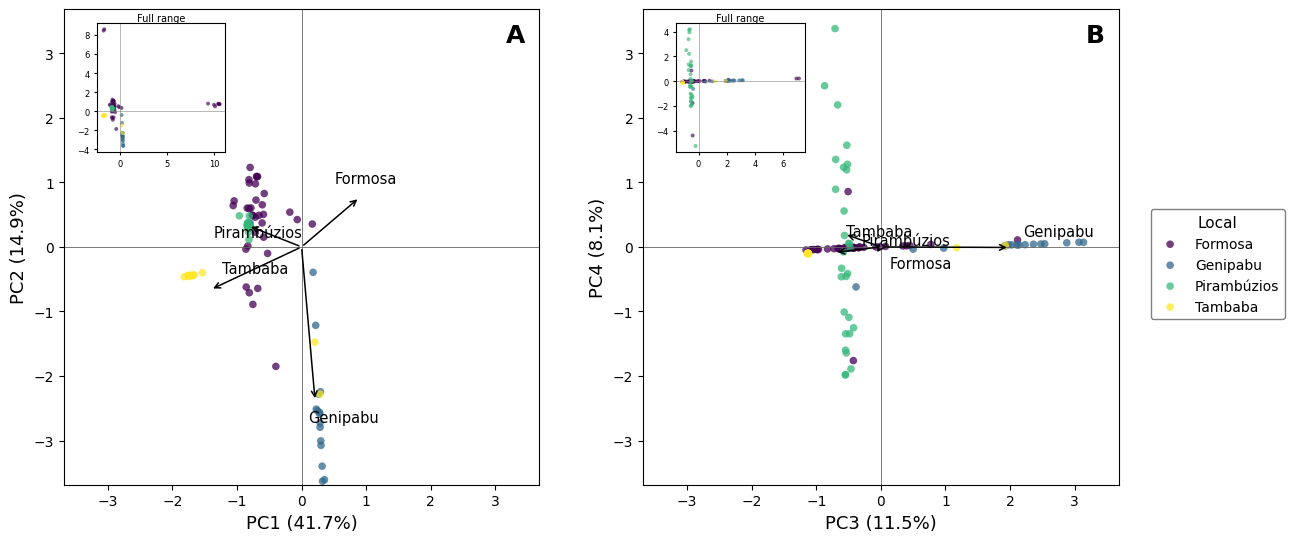

In [10]:
morfo['local_clean'] = morfo['local'].str.strip().str.capitalize()

df_plot = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'PC3': X_pca[:, 2],
    'PC4': X_pca[:, 3],
    'Local': morfo['local_clean']
})

means_A = df_plot.groupby('Local')[['PC1', 'PC2']].mean()
means_B = df_plot.groupby('Local')[['PC3', 'PC4']].mean()

locals_unique = sorted(df_plot['Local'].dropna().unique())
cmap = plt.colormaps['viridis'].resampled(len(locals_unique))
color_dict = {loc: cmap(i) for i, loc in enumerate(locals_unique)}

scores = df_plot[['PC1', 'PC2', 'PC3', 'PC4']].to_numpy()
lim = np.quantile(np.abs(scores), 0.95) * 1.20

print(f'Main-panel limits: {-lim:.2f} to {lim:.2f}')
print('All observations are retained; extreme values are shown in the insets.')

offsets_A = {
    'Formosa': (-18, 10),
    'Genipabu': (-5, -15),
    'Pirambúzios': (-25, -8),
    'Tambaba': (8, 12)
}

offsets_B = {
    'Formosa': (10, -10),
    'Genipabu': (10, 8),
    'Pirambúzios': (12, -8),
    'Tambaba': (8, 12)
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8))

def plot_panel(ax, pcx, pcy, means, panel, offsets):
    for local, color in color_dict.items():
        sub = df_plot[df_plot['Local'] == local]
        ax.scatter(sub[pcx], sub[pcy], s=30, alpha=0.75,
                   color=color, edgecolors='none', label=local)

    for local, row in means.iterrows():
        x, y = row[pcx], row[pcy]
        ax.annotate('', xy=(x, y), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', lw=1.1, color='black'))
        dx, dy = offsets.get(local, (8, 8))
        ax.annotate(local, xy=(x, y), xytext=(dx, dy),
                    textcoords='offset points', fontsize=10.5)

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal', adjustable='box')
    ax.axhline(0, color='0.4', lw=0.6)
    ax.axvline(0, color='0.4', lw=0.6)
    ax.grid(False)

    ix = int(pcx[-1]) - 1
    iy = int(pcy[-1]) - 1

    ax.set_xlabel(f'{pcx} ({pca.explained_variance_ratio_[ix]*100:.1f}%)', fontsize=13)
    ax.set_ylabel(f'{pcy} ({pca.explained_variance_ratio_[iy]*100:.1f}%)', fontsize=13)

    ax.text(0.97, 0.97, panel, transform=ax.transAxes,
            fontsize=18, fontweight='bold', ha='right', va='top')

    # Full-range inset
    ins = ax.inset_axes([0.07, 0.70, 0.27, 0.27])

    for local, color in color_dict.items():
        sub = df_plot[df_plot['Local'] == local]
        ins.scatter(sub[pcx], sub[pcy], s=8, alpha=0.65,
                    color=color, edgecolors='none')

    ins.axhline(0, color='0.5', lw=0.4)
    ins.axvline(0, color='0.5', lw=0.4)
    ins.tick_params(labelsize=6, length=2)
    ins.grid(False)
    ins.set_title('Full range', fontsize=7, pad=-1)

plot_panel(axes[0], 'PC1', 'PC2', means_A, 'A', offsets_A)
plot_panel(axes[1], 'PC3', 'PC4', means_B, 'B', offsets_B)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles, labels,
    title='Local',
    loc='center left',
    bbox_to_anchor=(0.91, 0.5),
    frameon=True,
    framealpha=1,
    edgecolor='0.5',
    facecolor='white',
    fontsize=10,
    title_fontsize=11
)

plt.subplots_adjust(
    left=0.05,
    right=0.92,
    bottom=0.12,
    top=0.94,
    wspace=0.05
)

plt.savefig(
    'PCA_PC1_PC2_PC3_PC4_biplot.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [11]:
cols_env = ['ph', 'temperature', 'oxygen', 'ec', 'salinity', 'ppt']

# One environmental record per Sample
env_vif = morfo[['Sample'] + cols_env].drop_duplicates('Sample').copy()
env_vif[cols_env] = env_vif[cols_env].replace(
    ["NA", "NaN", "nan", ".", "", " ", "null", "NULL", "-"], np.nan
)

env_vif[cols_env] = env_vif[cols_env].apply(
    lambda col: pd.to_numeric(col.astype(str).str.replace(",", ".", regex=False), errors="coerce")
)

print(f'Unique samples: {env_vif["Sample"].nunique()}')
print('\nMissing values by variable:')
print(env_vif[cols_env].isna().sum())

# Median imputation at Sample level
env_vif[cols_env] = env_vif[cols_env].fillna(env_vif[cols_env].median())

if env_vif[cols_env].isna().any().any():
    raise ValueError('Some environmental variables contain only missing values.')

# Correlation matrices
pearson_corr = env_vif[cols_env].corr(method='pearson')
spearman_corr = env_vif[cols_env].corr(method='spearman')

print('\nPearson correlation matrix:')
print(pearson_corr.round(3))

print('\nSpearman correlation matrix:')
print(spearman_corr.round(3))

def calculate_vif(data):
    if data.shape[1] == 1:
        return pd.Series(1.0, index=data.columns)
    Xv = sm.add_constant(data, has_constant='add')
    return pd.Series(
        [variance_inflation_factor(Xv.values, i) for i in range(1, Xv.shape[1])],
        index=data.columns
    )

VIF_THRESHOLD = 10
STABILITY_THRESHOLD = 0.80

all_orders = list(permutations(cols_env))
n_orders = len(all_orders)

selection_count = dict.fromkeys(cols_env, 0)
position_count = {v: np.zeros(len(cols_env), dtype=int) for v in cols_env}
position_selected = {v: np.zeros(len(cols_env), dtype=int) for v in cols_env}
vif_selected = {v: [] for v in cols_env}

for order in all_orders:
    selected = []
    for pos, var in enumerate(order):
        position_count[var][pos] += 1
        candidate = selected + [var]
        vif = calculate_vif(env_vif[candidate])
        if np.all(vif < VIF_THRESHOLD):
            selected.append(var)
            position_selected[var][pos] += 1
            vif_selected[var].append(vif[var])
    for var in selected:
        selection_count[var] += 1

stability = pd.DataFrame({
    'variable': cols_env,
    'selected_n': [selection_count[v] for v in cols_env],
    'stability': [selection_count[v] / n_orders for v in cols_env],
    'mean_vif_when_selected': [
        np.mean(vif_selected[v]) if vif_selected[v] else np.nan
        for v in cols_env
    ]
})

stability['stable'] = stability['stability'] >= STABILITY_THRESHOLD
stability = stability.sort_values('stability', ascending=False).reset_index(drop=True)

print(f'\nTotal orders tested: {n_orders}')
print(f'Each variable appears {n_orders // len(cols_env)} times in each position')
print('\nVIF stability results:')
print(stability)

position_stability = pd.DataFrame(index=cols_env)

for pos in range(len(cols_env)):
    position_stability[f'position_{pos+1}'] = [
        position_selected[v][pos] / position_count[v][pos]
        for v in cols_env
    ]

print('\nSelection stability by entry position:')
print(position_stability)

cols_env_selected = stability.loc[
    stability['stability'] >= STABILITY_THRESHOLD, 'variable'
].tolist()

print('\nVariables with stability >= 80%:')
print(cols_env_selected)

final_vif = calculate_vif(env_vif[cols_env_selected])

while len(final_vif) > 1 and final_vif.max() >= VIF_THRESHOLD:
    remove_var = final_vif.idxmax()
    print(f'Removing {remove_var}: VIF = {final_vif[remove_var]:.2f}')
    cols_env_selected.remove(remove_var)
    final_vif = calculate_vif(env_vif[cols_env_selected])

final_vif_table = pd.DataFrame({
    'variable': final_vif.index,
    'VIF': final_vif.values
})

print('\nFinal selected variables:')
print(cols_env_selected)

print('\nFinal VIF:')
print(final_vif_table)

Unique samples: 43

Missing values by variable:
ph             0
temperature    0
oxygen         0
ec             0
salinity       0
ppt            0
dtype: int64

Pearson correlation matrix:
                ph  temperature  oxygen     ec  salinity    ppt
ph           1.000        0.314   0.205  0.359    -0.121  0.401
temperature  0.314        1.000  -0.128  0.060     0.609  0.263
oxygen       0.205       -0.128   1.000  0.376    -0.027  0.466
ec           0.359        0.060   0.376  1.000     0.074  0.278
salinity    -0.121        0.609  -0.027  0.074     1.000 -0.049
ppt          0.401        0.263   0.466  0.278    -0.049  1.000

Spearman correlation matrix:
                ph  temperature  oxygen     ec  salinity    ppt
ph           1.000        0.021   0.049 -0.146    -0.061 -0.137
temperature  0.021        1.000  -0.020  0.318     0.553  0.132
oxygen       0.049       -0.020   1.000  0.224     0.042 -0.180
ec          -0.146        0.318   0.224  1.000     0.582  0.406
salinity  

Observations: 106
Species: 6
Localities: 4
Samples: 41
Locality reference: Formosa
PCs used: 4
Cumulative variance explained: 76.17%


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta, beta_size, beta_locality, sigma_species, z_species, sigma_sample, z_sample, sigma]


Output()

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 12538 seconds.
Sampling: [y_obs]


Output()


PC1 results
    PC                   parameter   mean     sd  hdi_2.5%  hdi_97.5%  \
0  PC1                    beta[ph] -0.012  0.033    -0.077      0.052   
1  PC1           beta[temperature]  0.022  0.048    -0.071      0.118   
2  PC1                beta[oxygen]  0.037  0.027    -0.017      0.088   
3  PC1                    beta[ec] -0.018  0.032    -0.079      0.045   
4  PC1              beta[salinity] -0.014  0.038    -0.087      0.061   
5  PC1                   beta[ppt] -0.037  0.026    -0.090      0.014   
6  PC1                   beta_size -0.069  0.051    -0.170      0.031   
7  PC1     beta_locality[Genipabu] -0.117  0.224    -0.541      0.342   
8  PC1  beta_locality[Pirambúzios] -0.151  0.121    -0.390      0.081   
9  PC1      beta_locality[Tambaba] -0.085  0.266    -0.608      0.440   

   mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat  
0      0.000    0.000    7306.0    8384.0    1.0  
1      0.001    0.000    5980.0    7317.0    1.0  
2      0.000    0.000    7933.

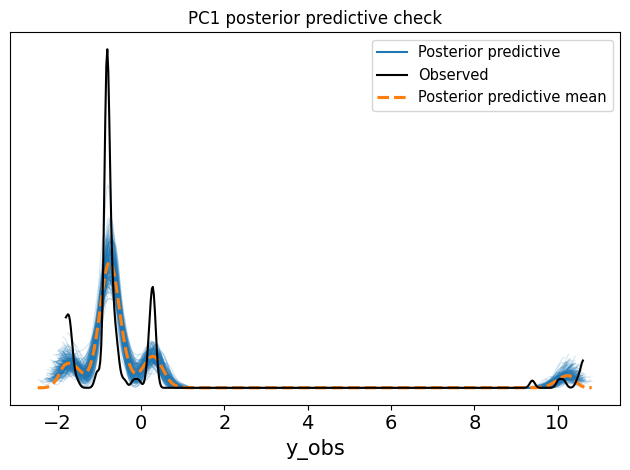

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta, beta_size, beta_locality, sigma_species, z_species, sigma_sample, z_sample, sigma]


Output()

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 5499 seconds.
Sampling: [y_obs]


Output()


PC2 results
    PC                   parameter   mean     sd  hdi_2.5%  hdi_97.5%  \
0  PC2                    beta[ph]  0.074  0.085    -0.096      0.236   
1  PC2           beta[temperature]  0.067  0.132    -0.192      0.323   
2  PC2                beta[oxygen]  0.056  0.074    -0.095      0.195   
3  PC2                    beta[ec]  0.036  0.085    -0.128      0.203   
4  PC2              beta[salinity] -0.030  0.101    -0.236      0.158   
5  PC2                   beta[ppt] -0.055  0.073    -0.196      0.088   
6  PC2                   beta_size  0.074  0.140    -0.202      0.350   
7  PC2     beta_locality[Genipabu] -0.096  0.484    -1.058      0.823   
8  PC2  beta_locality[Pirambúzios]  0.085  0.295    -0.476      0.677   
9  PC2      beta_locality[Tambaba]  0.316  0.561    -0.772      1.401   

   mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat  
0      0.001    0.001    8746.0    8663.0    1.0  
1      0.002    0.001    6940.0    7784.0    1.0  
2      0.001    0.001    6640.

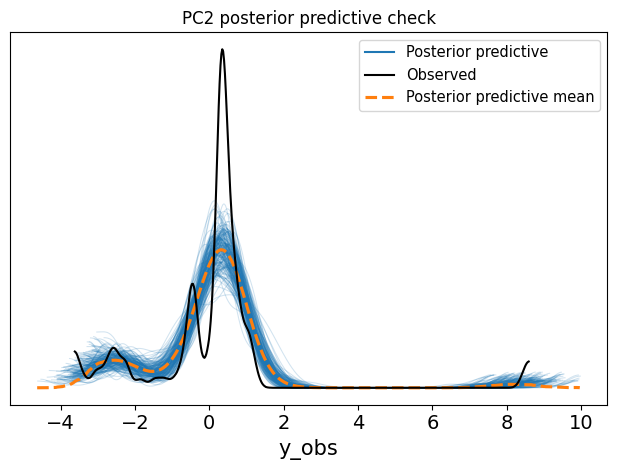

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta, beta_size, beta_locality, sigma_species, z_species, sigma_sample, z_sample, sigma]


Output()

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 5823 seconds.
Sampling: [y_obs]


Output()


PC3 results
    PC                   parameter   mean     sd  hdi_2.5%  hdi_97.5%  \
0  PC3                    beta[ph] -0.080  0.077    -0.227      0.076   
1  PC3           beta[temperature] -0.000  0.121    -0.230      0.244   
2  PC3                beta[oxygen] -0.047  0.067    -0.177      0.087   
3  PC3                    beta[ec] -0.015  0.078    -0.167      0.136   
4  PC3              beta[salinity] -0.004  0.092    -0.180      0.180   
5  PC3                   beta[ppt]  0.041  0.067    -0.091      0.175   
6  PC3                   beta_size -0.113  0.127    -0.359      0.138   
7  PC3     beta_locality[Genipabu] -0.020  0.452    -0.894      0.874   
8  PC3  beta_locality[Pirambúzios] -0.254  0.272    -0.808      0.264   
9  PC3      beta_locality[Tambaba] -0.377  0.528    -1.442      0.631   

   mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat  
0      0.001    0.001   11645.0    9097.0    1.0  
1      0.001    0.001    9617.0    8778.0    1.0  
2      0.001    0.001    9606.

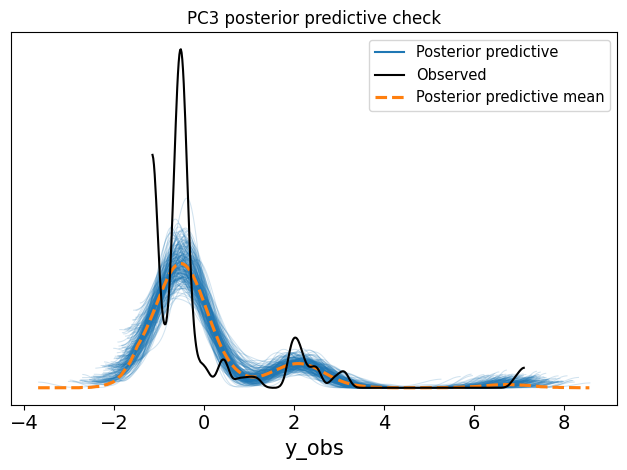

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta, beta_size, beta_locality, sigma_species, z_species, sigma_sample, z_sample, sigma]


Output()

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 1687 seconds.
Sampling: [y_obs]


Output()


PC4 results
    PC                   parameter   mean     sd  hdi_2.5%  hdi_97.5%  \
0  PC4                    beta[ph]  0.293  0.194    -0.089      0.676   
1  PC4           beta[temperature] -0.089  0.231    -0.529      0.371   
2  PC4                beta[oxygen] -0.015  0.158    -0.322      0.293   
3  PC4                    beta[ec] -0.084  0.190    -0.473      0.276   
4  PC4              beta[salinity] -0.128  0.201    -0.523      0.262   
5  PC4                   beta[ppt] -0.044  0.151    -0.338      0.251   
6  PC4                   beta_size  0.119  0.207    -0.292      0.519   
7  PC4     beta_locality[Genipabu]  0.044  0.529    -1.005      1.052   
8  PC4  beta_locality[Pirambúzios]  0.890  0.511    -0.112      1.909   
9  PC4      beta_locality[Tambaba]  0.041  0.526    -0.996      1.074   

   mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat  
0      0.003    0.002    5395.0    7318.0    1.0  
1      0.003    0.002    5103.0    6945.0    1.0  
2      0.002    0.001    7160.

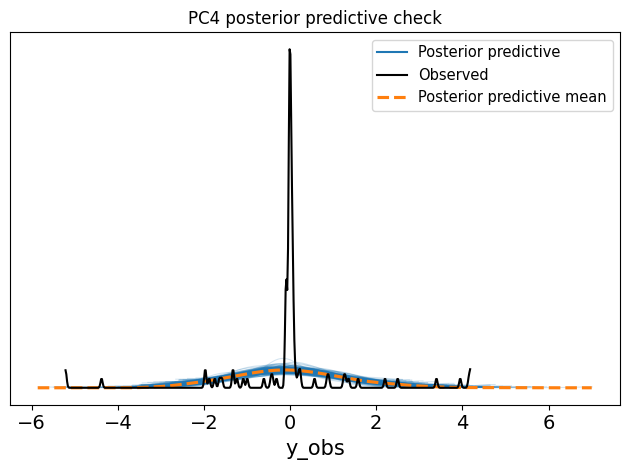


Bayesian diagnostics summary
    PC  max_Rhat  min_ESS_bulk  min_ESS_tail  divergences  PPC_RMSE  \
0  PC1       1.0        2770.0        1887.0            0  0.145198   
1  PC2       1.0        3135.0        3561.0            0  0.440545   
2  PC3       1.0        3563.0        4835.0            0  0.400085   
3  PC4       1.0        3522.0        2638.0            0  0.898472   

   PPC_coverage_95  
0         0.962264  
1         0.962264  
2         0.952830  
3         0.971698  

Environmental, body-size and locality effects
     PC                   parameter   mean     sd  hdi_2.5%  hdi_97.5%  \
0   PC1                    beta[ph] -0.012  0.033    -0.077      0.052   
1   PC1           beta[temperature]  0.022  0.048    -0.071      0.118   
2   PC1                beta[oxygen]  0.037  0.027    -0.017      0.088   
3   PC1                    beta[ec] -0.018  0.032    -0.079      0.045   
4   PC1              beta[salinity] -0.014  0.038    -0.087      0.061   
5   PC1           

In [12]:
cols_env = ['ph', 'temperature', 'oxygen', 'ec', 'salinity', 'ppt']
cols_env_selected = cols_env.copy()
pc_cols = ['PC1', 'PC2', 'PC3', 'PC4']

# Prepare data
df_model = morfo[['Sample', 'local', 'species', 'size'] + cols_env].copy()
df_model[pc_cols] = X_pca[:, :4]

for col in cols_env:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

df_model['size'] = pd.to_numeric(
    df_model['size'].astype('string').str.replace(',', '.', regex=False),
    errors='coerce'
)

if df_model[cols_env].isna().any().any():
    raise ValueError('Environmental variables contain missing or non-numeric values.')

df_model = df_model.dropna(
    subset=['Sample', 'local', 'species', 'size'] + pc_cols
).reset_index(drop=True)

# Sample nested within locality
df_model['sample_nested'] = (
    df_model['local'].astype(str).str.strip() + ' | ' +
    df_model['Sample'].astype(str).str.strip()
)

# Standardize environmental predictors
X = df_model[cols_env_selected].to_numpy(dtype=float)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_std[X_std == 0] = 1
X = (X - X_mean) / X_std

# Standardize body size
size = df_model['size'].to_numpy(dtype=float)
size_std = size.std()
if size_std == 0:
    size_std = 1
size = (size - size.mean()) / size_std

# Species
species_cat = pd.Categorical(df_model['species'])
species_idx = species_cat.codes
species_names = species_cat.categories.tolist()

# Sample
sample_cat = pd.Categorical(df_model['sample_nested'])
sample_idx = sample_cat.codes
sample_names = sample_cat.categories.tolist()

# Locality
locality_levels = sorted(df_model['local'].astype(str).unique())
locality_cat = pd.Categorical(df_model['local'].astype(str), categories=locality_levels)
locality_matrix = pd.get_dummies(locality_cat, drop_first=True, dtype=float).to_numpy()
locality_names = locality_levels[1:]

print(f'Observations: {len(df_model)}')
print(f'Species: {len(species_names)}')
print(f'Localities: {len(locality_levels)}')
print(f'Samples: {len(sample_names)}')
print(f'Locality reference: {locality_levels[0]}')
print(f'PCs used: {len(pc_cols)}')
print(f'Cumulative variance explained: {pca.explained_variance_ratio_[:4].sum()*100:.2f}%')

def fit_bayesian_pc(y, name):
    coords = {
        'species': species_names,
        'sample': sample_names,
        'predictor': cols_env_selected,
        'locality': locality_names
    }

    with pm.Model(coords=coords) as model:
        intercept = pm.Normal('intercept', 0, 1)
        beta = pm.Normal('beta', 0, 1, dims='predictor')
        beta_size = pm.Normal('beta_size', 0, 1)
        beta_locality = pm.Normal('beta_locality', 0, 1, dims='locality')

        sigma_species = pm.HalfNormal('sigma_species', 1)
        z_species = pm.Normal('z_species', 0, 1, dims='species')
        species_effect = pm.Deterministic(
            'species_effect', z_species * sigma_species, dims='species'
        )

        sigma_sample = pm.HalfNormal('sigma_sample', 1)
        z_sample = pm.Normal('z_sample', 0, 1, dims='sample')
        sample_effect = pm.Deterministic(
            'sample_effect', z_sample * sigma_sample, dims='sample'
        )

        sigma = pm.HalfNormal('sigma', 1)

        mu = (
            intercept +
            pm.math.dot(X, beta) +
            beta_size * size +
            pm.math.dot(locality_matrix, beta_locality) +
            species_effect[species_idx] +
            sample_effect[sample_idx]
        )

        pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

        trace = pm.sample(
            draws=3000,
            tune=3000,
            chains=4,
            target_accept=0.99,
            random_seed=42,
            return_inferencedata=True
        )

        trace = pm.sample_posterior_predictive(
            trace,
            var_names=['y_obs'],
            random_seed=42,
            extend_inferencedata=True
        )

    return model, trace

def bayesian_diagnostics(trace, y, name):
    vars_diag = [
        'intercept', 'beta', 'beta_size', 'beta_locality',
        'sigma_species', 'sigma_sample', 'sigma',
        'species_effect', 'sample_effect'
    ]

    summary = az.summary(trace, var_names=vars_diag, hdi_prob=0.95)
    max_rhat = summary['r_hat'].max()
    min_ess_bulk = summary['ess_bulk'].min()
    min_ess_tail = summary['ess_tail'].min()
    divergences = int(trace.sample_stats['diverging'].sum().values)

    pp = trace.posterior_predictive['y_obs'].values.reshape(-1, len(y))
    pp_mean = pp.mean(axis=0)
    lower = np.quantile(pp, 0.025, axis=0)
    upper = np.quantile(pp, 0.975, axis=0)

    rmse_pp = np.sqrt(np.mean((y - pp_mean) ** 2))
    coverage = np.mean((y >= lower) & (y <= upper))

    diagnostics = {
        'PC': name,
        'max_Rhat': max_rhat,
        'min_ESS_bulk': min_ess_bulk,
        'min_ESS_tail': min_ess_tail,
        'divergences': divergences,
        'PPC_RMSE': rmse_pp,
        'PPC_coverage_95': coverage
    }

    effects = az.summary(
        trace,
        var_names=['beta', 'beta_size', 'beta_locality'],
        hdi_prob=0.95
    ).reset_index().rename(columns={'index': 'parameter'})
    effects.insert(0, 'PC', name)

    print(f'\n{name} results')
    print(effects)
    print(f'\n{name} diagnostics')
    print(f'Maximum R-hat: {max_rhat:.4f}')
    print(f'Minimum bulk ESS: {min_ess_bulk:.0f}')
    print(f'Minimum tail ESS: {min_ess_tail:.0f}')
    print(f'Divergences: {divergences}')
    print(f'Posterior predictive RMSE: {rmse_pp:.3f}')
    print(f'95% posterior predictive coverage: {coverage*100:.1f}%')

    az.plot_ppc(trace, num_pp_samples=200)
    plt.title(f'{name} posterior predictive check')
    plt.tight_layout()
    plt.show()

    return summary, diagnostics, effects

models = {}
traces = {}
summaries = {}
diagnostics_all = []
effects_all = []

for pc in pc_cols:
    y = df_model[pc].to_numpy(dtype=float)
    models[pc], traces[pc] = fit_bayesian_pc(y, pc)
    summaries[pc], diag, effects = bayesian_diagnostics(traces[pc], y, pc)
    diagnostics_all.append(diag)
    effects_all.append(effects)

diagnostics_table = pd.DataFrame(diagnostics_all)
effects_table = pd.concat(effects_all, ignore_index=True)

print('\nBayesian diagnostics summary')
print(diagnostics_table)

print('\nEnvironmental, body-size and locality effects')
print(effects_table)

model_pc1, model_pc2 = models['PC1'], models['PC2']
model_pc3, model_pc4 = models['PC3'], models['PC4']

trace_pc1, trace_pc2 = traces['PC1'], traces['PC2']
trace_pc3, trace_pc4 = traces['PC3'], traces['PC4']

summary_pc1, summary_pc2 = summaries['PC1'], summaries['PC2']
summary_pc3, summary_pc4 = summaries['PC3'], summaries['PC4']

In [13]:
cols_env = ['ph', 'temperature', 'oxygen', 'ec', 'salinity', 'ppt']

In [14]:
summary_pc1 = az.summary(trace_pc1, var_names=["beta"])
summary_pc2 = az.summary(trace_pc2, var_names=["beta"])
summary_pc3 = az.summary(trace_pc3, var_names=["beta"])

summary_pc1['variable'] = cols_env
summary_pc2['variable'] = cols_env
summary_pc3['variable'] = cols_env

print(f"Summary PC1:\n{summary_pc1}")
print(f"Summary PC2:\n{summary_pc2}")
print(f"Summary PC3:\n{summary_pc3}")

Summary PC1:
                    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
beta[ph]          -0.012  0.033  -0.073    0.051      0.000      0.0   
beta[temperature]  0.022  0.048  -0.067    0.114      0.001      0.0   
beta[oxygen]       0.037  0.027  -0.012    0.088      0.000      0.0   
beta[ec]          -0.018  0.032  -0.078    0.041      0.000      0.0   
beta[salinity]    -0.014  0.038  -0.082    0.060      0.000      0.0   
beta[ppt]         -0.037  0.026  -0.085    0.015      0.000      0.0   

                   ess_bulk  ess_tail  r_hat     variable  
beta[ph]             7306.0    8384.0    1.0           ph  
beta[temperature]    5980.0    7317.0    1.0  temperature  
beta[oxygen]         7933.0    8709.0    1.0       oxygen  
beta[ec]             9491.0    8590.0    1.0           ec  
beta[salinity]       6170.0    7510.0    1.0     salinity  
beta[ppt]            8143.0    8627.0    1.0          ppt  
Summary PC2:
                    mean     sd  hdi_3%  hdi_97% 

In [15]:
cols_env = ['ph', 'temperature', 'oxygen', 'ec', 'salinity', 'ppt']
traces_pc = {
    'PC1': trace_pc1,
    'PC2': trace_pc2,
    'PC3': trace_pc3,
    'PC4': trace_pc4
}

summaries_beta = {}

for pc, trace in traces_pc.items():
    summary = az.summary(
        trace,
        var_names=['beta'],
        hdi_prob=0.95
    ).reset_index()

    summary['variable'] = cols_env
    summary = summary[
        ['variable', 'mean', 'sd', 'hdi_2.5%', 'hdi_97.5%',
         'ess_bulk', 'ess_tail', 'r_hat']
    ]
    summary = summary.sort_values('mean', ascending=False).reset_index(drop=True)
    summaries_beta[pc] = summary

    print(f'\n{pc} results')
    print(summary.to_string(index=False))

summary_pc1 = summaries_beta['PC1']
summary_pc2 = summaries_beta['PC2']
summary_pc3 = summaries_beta['PC3']
summary_pc4 = summaries_beta['PC4']

summary_all = pd.concat(
    [df.assign(PC=pc) for pc, df in summaries_beta.items()],
    ignore_index=True
)

summary_all = summary_all[
    ['PC', 'variable', 'mean', 'sd', 'hdi_2.5%', 'hdi_97.5%',
     'ess_bulk', 'ess_tail', 'r_hat']
]

print('\nAll PCs')
print(summary_all.to_string(index=False))


PC1 results
   variable   mean    sd  hdi_2.5%  hdi_97.5%  ess_bulk  ess_tail  r_hat
     oxygen  0.037 0.027    -0.017      0.088    7933.0    8709.0    1.0
temperature  0.022 0.048    -0.071      0.118    5980.0    7317.0    1.0
         ph -0.012 0.033    -0.077      0.052    7306.0    8384.0    1.0
   salinity -0.014 0.038    -0.087      0.061    6170.0    7510.0    1.0
         ec -0.018 0.032    -0.079      0.045    9491.0    8590.0    1.0
        ppt -0.037 0.026    -0.090      0.014    8143.0    8627.0    1.0

PC2 results
   variable   mean    sd  hdi_2.5%  hdi_97.5%  ess_bulk  ess_tail  r_hat
         ph  0.074 0.085    -0.096      0.236    8746.0    8663.0    1.0
temperature  0.067 0.132    -0.192      0.323    6940.0    7784.0    1.0
     oxygen  0.056 0.074    -0.095      0.195    6640.0    7794.0    1.0
         ec  0.036 0.085    -0.128      0.203    9303.0    8763.0    1.0
   salinity -0.030 0.101    -0.236      0.158    6861.0    7070.0    1.0
        ppt -0.055 0.073 

             count      mean    median
Locality                              
Formosa         16  0.460010  0.326391
Genipabu        10  0.508409  0.393275
Pirambúzios     10  1.121019  1.007131
Tambaba         10  0.285331  0.174763


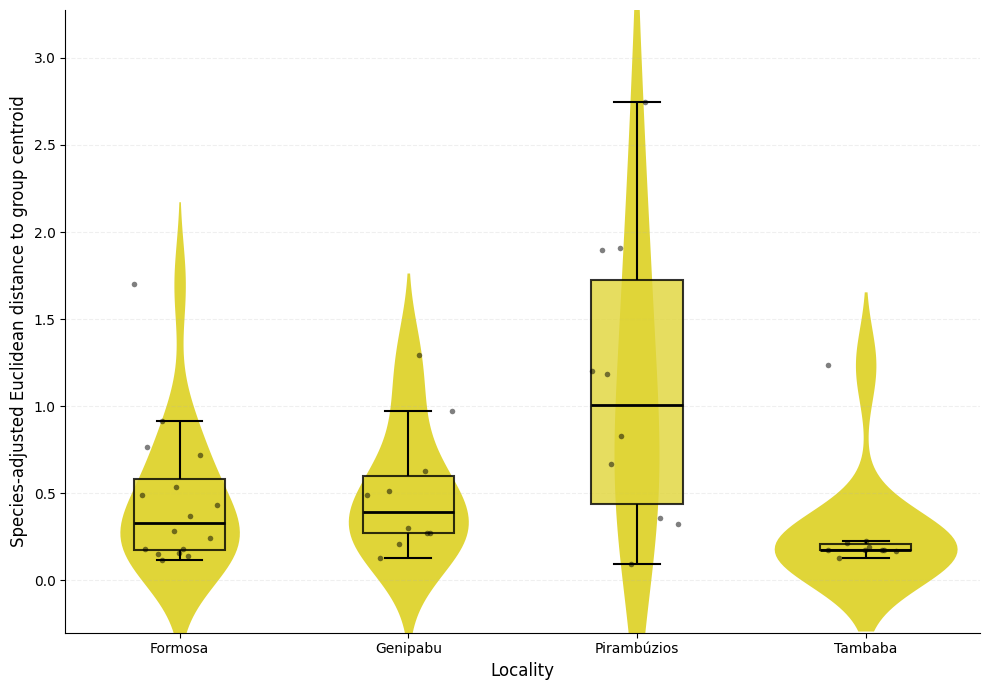

In [19]:
NEON_YELLOW = "#FCED1C"
pc_cols = ['PC1', 'PC2', 'PC3', 'PC4']

# Prepare Sample × species units
mask = morfo[['Sample', 'local', 'species']].notna().all(axis=1).to_numpy()
perm_data = morfo.loc[mask, ['Sample', 'local', 'species']].reset_index(drop=True)
perm_data[pc_cols] = X_pca[mask, :4]
perm_data = perm_data.groupby(['Sample', 'local', 'species'], as_index=False)[pc_cols].mean()

Y = perm_data[pc_cols].to_numpy()
groups = perm_data['local'].astype(str).to_numpy()

# Remove species effect
species_dummies = pd.get_dummies(
    perm_data['species'].astype('category'),
    drop_first=True,
    dtype=float
).to_numpy()

X_species = np.column_stack([np.ones(len(perm_data)), species_dummies])
beta = np.linalg.lstsq(X_species, Y, rcond=None)[0]
Y_species_resid = Y - X_species @ beta

# Distance to locality centroid
distances = []
for local in np.unique(groups):
    idx = groups == local
    centroid = Y_species_resid[idx].mean(axis=0)
    for distance in np.linalg.norm(Y_species_resid[idx] - centroid, axis=1):
        distances.append({'Locality': local, 'Distance': distance})

df_permdisp = pd.DataFrame(distances)
order = ['Formosa', 'Genipabu', 'Pirambúzios', 'Tambaba']

# FDR-adjusted pairwise PERMDISP letters
letters = {
    'Formosa': '',
    'Genipabu': '',
    'Pirambúzios': '',
    'Tambaba': ''
}

print(df_permdisp.groupby('Locality')['Distance'].agg(['count', 'mean', 'median']))

y_min = df_permdisp['Distance'].min()
y_max = df_permdisp['Distance'].max()
amplitude = y_max - y_min

plt.figure(figsize=(10, 7))

sns.violinplot(
    data=df_permdisp, x='Locality', y='Distance', order=order,
    color=NEON_YELLOW, inner=None, linewidth=0, cut=2
)

ax = sns.boxplot(
    data=df_permdisp, x='Locality', y='Distance', order=order,
    color=NEON_YELLOW, width=0.4, linewidth=1.5,
    showmeans=False, fliersize=0,
    boxprops=dict(edgecolor='black', alpha=0.8),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

sns.stripplot(
    data=df_permdisp, x='Locality', y='Distance', order=order,
    color='black', size=4, jitter=0.2, alpha=0.5, ax=ax
)

for i, local in enumerate(order):
    group_max = df_permdisp.loc[df_permdisp['Locality'] == local, 'Distance'].max()
    ax.text(
        i, group_max + amplitude * 0.08, letters[local],
        ha='center', va='bottom', fontsize=18, fontweight='bold'
    )

plt.ylim(y_min - amplitude * 0.15, y_max + amplitude * 0.2)
plt.ylabel('Species-adjusted Euclidean distance to group centroid', fontsize=12)
plt.xlabel('Locality', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.2)
sns.despine()
plt.tight_layout()
plt.savefig('permdisp_species_adjusted.png', dpi=600, bbox_inches='tight')
plt.show()

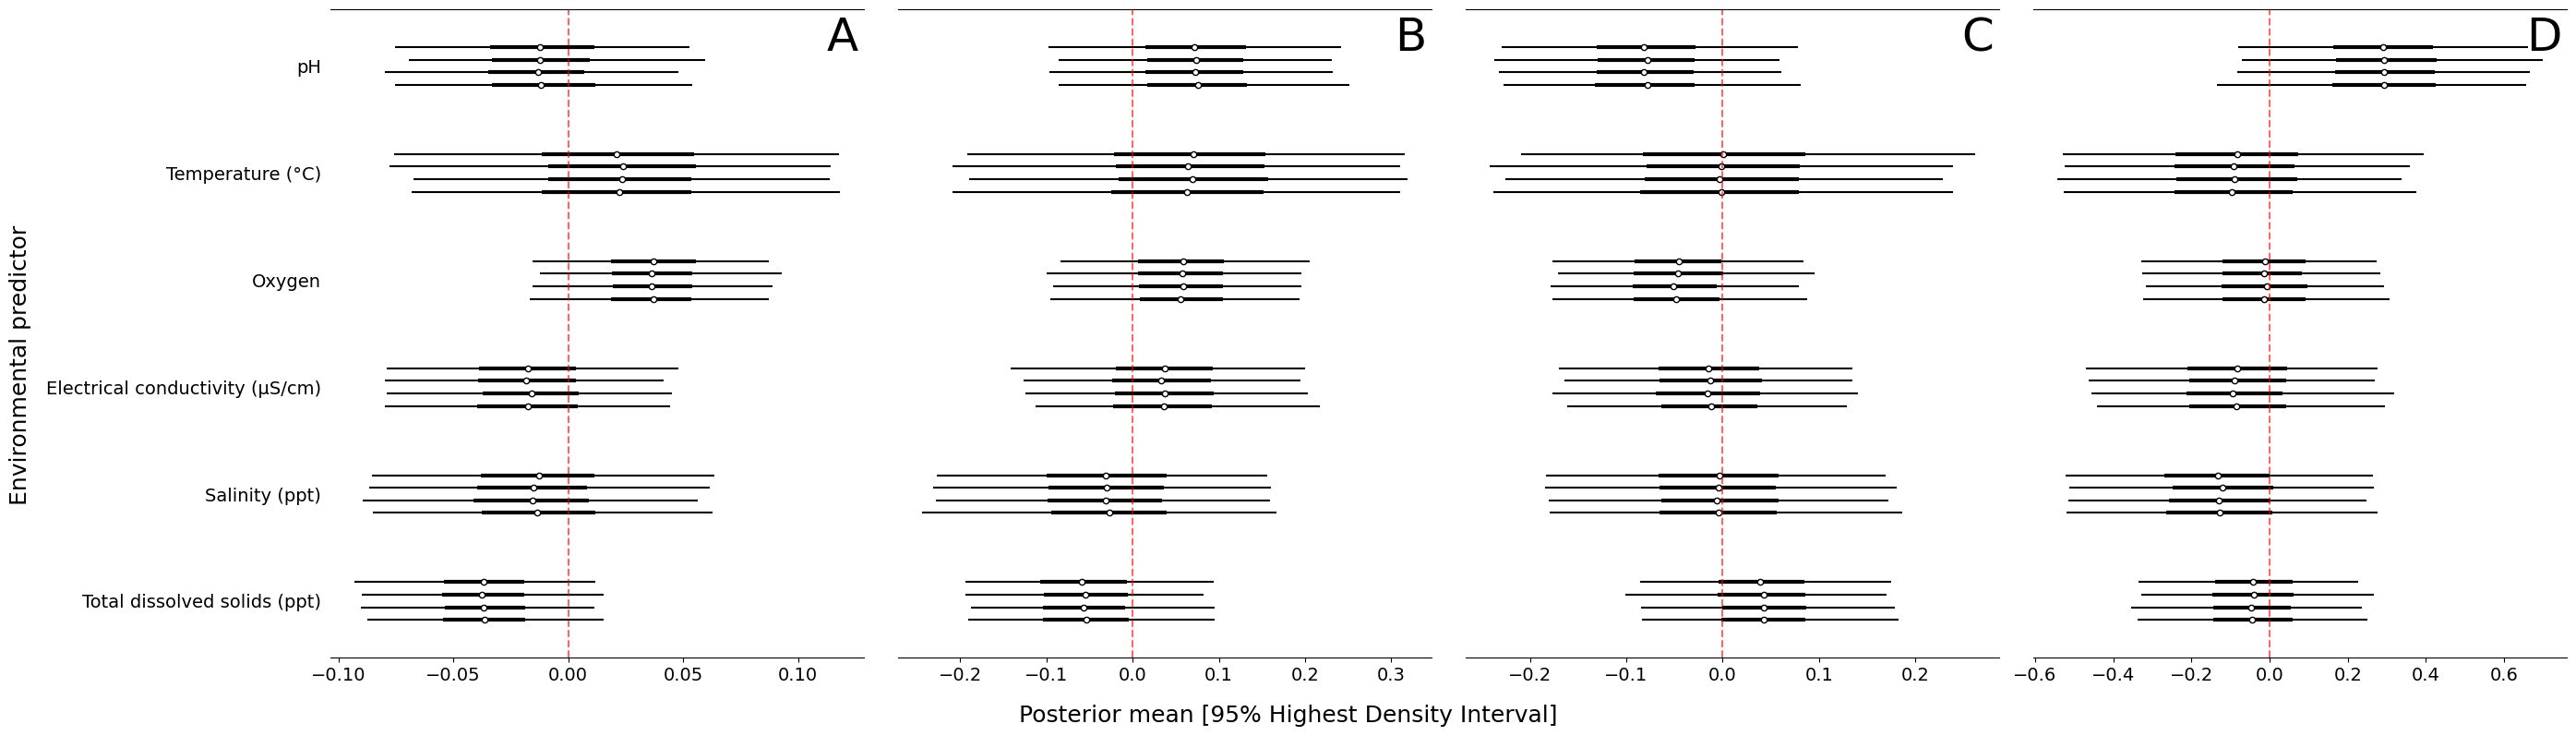


Panel A
pH: -0.012 [-0.077, 0.052]
Temperature (°C): 0.022 [-0.071, 0.118]
Oxygen: 0.037 [-0.017, 0.088]
Electrical conductivity (µS/cm): -0.018 [-0.079, 0.045]
Salinity (ppt): -0.014 [-0.087, 0.061]
Total dissolved solids (ppt): -0.037 [-0.090, 0.014]

Panel B
pH: 0.074 [-0.096, 0.236]
Temperature (°C): 0.067 [-0.192, 0.323]
Oxygen: 0.056 [-0.095, 0.195]
Electrical conductivity (µS/cm): 0.036 [-0.128, 0.203]
Salinity (ppt): -0.030 [-0.236, 0.158]
Total dissolved solids (ppt): -0.055 [-0.196, 0.088]

Panel C
pH: -0.080 [-0.227, 0.076]
Temperature (°C): -0.000 [-0.230, 0.244]
Oxygen: -0.047 [-0.177, 0.087]
Electrical conductivity (µS/cm): -0.015 [-0.167, 0.136]
Salinity (ppt): -0.004 [-0.180, 0.180]
Total dissolved solids (ppt): 0.041 [-0.091, 0.175]

Panel D
pH: 0.293 [-0.089, 0.676]
Temperature (°C): -0.089 [-0.529, 0.371]
Oxygen: -0.015 [-0.322, 0.293]
Electrical conductivity (µS/cm): -0.084 [-0.473, 0.276]
Salinity (ppt): -0.128 [-0.523, 0.262]
Total dissolved solids (ppt): -0.044 

In [21]:
cols_env_labels = [
    'pH',
    'Temperature (°C)',
    'Oxygen',
    'Electrical conductivity (µS/cm)',
    'Salinity (ppt)',
    'Total dissolved solids (ppt)'
]

traces_plot = [trace_pc1, trace_pc2, trace_pc3, trace_pc4]
panels = ['A', 'B', 'C', 'D']
summaries = []

fig, axes = plt.subplots(1, 4, figsize=(28, 8), sharey=True)

for ax, trace, panel in zip(axes, traces_plot, panels):
    az.plot_forest(
        trace,
        var_names=['beta'],
        combined=False,
        hdi_prob=0.95,
        ax=ax,
        colors='black'
    )

    ax.axvline(0, color='red', linestyle='--', alpha=0.6)
    ax.set_title('')
    ax.text(
        0.99, 0.99, panel,
        transform=ax.transAxes,
        fontsize=36,
        va='top',
        ha='right'
    )

    summary = az.summary(
        trace,
        var_names=['beta'],
        hdi_prob=0.95
    )

    summaries.append(summary)

ticks = axes[0].get_yticks()
axes[0].set_yticks(ticks)
axes[0].set_yticklabels(cols_env_labels[::-1])

fig.supxlabel(
    'Posterior mean [95% Highest Density Interval]',
    fontsize=18
)

fig.supylabel(
    'Environmental predictor',
    x=0.005,
    fontsize=18
)

plt.tight_layout()

plt.savefig(
    'forest_plots_PC1_PC2_PC3_PC4_95HDI_600dpi.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

# Statistical summary shown below the figure, but not included in the saved image
for panel, summary in zip(panels, summaries):
    print(f'\nPanel {panel}')
    for label, (_, row) in zip(cols_env_labels, summary.iterrows()):
        print(
            f'{label}: {row["mean"]:.3f} '
            f'[{row["hdi_2.5%"]:.3f}, {row["hdi_97.5%"]:.3f}]'
        )